In [37]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from collections import Counter


def load_and_clean_citations(file_path, column_name="raw_citation", 
                             output_path="deduplicated_citations.csv", show_stats=True):
    """
    Load a CSV file and return cleaned, filtered citations.

    Parameters:
        file_path (str): Path to the CSV file
        column_name (str): Name of the column containing citations

    Returns:
        citations (pd.Series): Filtered original citations
        citations_clean (pd.Series): Cleaned citations
    """

    ### Load data
    df = pd.read_csv(file_path, low_memory=False)

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in CSV")

    citations = df[column_name].dropna().reset_index(drop=True)

    ### Filter invalid citations 
    def is_valid_citation(text):
        text = str(text).lower().strip()

        # Remove very short entries
        if len(text.split()) < 5:
            return False

        bad_patterns = [
            "book chapter",
            "book chapters",
            "publications",
            "references",
            "bibliography",
            "refereed",
            "journal articles",
            "peer reviewed",
            "peer reviewed",
            "awarded",
            "granted",
            "grants",
            "under review",
            "appearances",
            "internship"
        ]

        if any(p in text for p in bad_patterns):
            return False

        return True

    citations = citations[citations.apply(is_valid_citation)].reset_index(drop=True)

    ### Clean text 
    def clean_citation(text):
        text = str(text).lower()

        ### Remove punctuation
        text = re.sub(r'[^\w\s]', ' ', text)

        ### Collapse whitespace
        text = re.sub(r'\s+', ' ', text)

        return text.strip()

    citations_clean = citations.apply(clean_citation)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000   # prevents noise explosion
    )

    X = vectorizer.fit_transform(citations_clean)
    
    nn = NearestNeighbors(metric="cosine", n_neighbors=5)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)
    
    threshold = 0.15  # distance (cosine distance = 1 - similarity)

    groups = []
    visited = set()

    for i in range(len(citations)):
        if i in visited:
            continue

        group = [i]

        for j, dist in zip(indices[i], distances[i]):
            if j != i and dist < threshold:
                group.append(j)
                visited.add(j)

        visited.add(i)

        if len(group) > 1:
            groups.append(group)
            
    unique_indices = set(range(len(citations)))

    for group in groups:
        for idx in group[1:]:  # keep first, remove rest
            unique_indices.discard(idx)

    unique_citations = citations.iloc[list(unique_indices)]
    df_unique = pd.DataFrame({
        "citation": unique_citations.reset_index(drop=True)
    })
    
    df_unique["num_words"] = df_unique["citation"].apply(lambda x: len(x.split()))
    df_unique["num_chars"] = df_unique["citation"].apply(len)
    
    min_words = 20
    min_chars = 100

    df_filtered = df_unique[
        (df_unique["num_words"] >= min_words) &
        (df_unique["num_chars"] >= min_chars)
    ].reset_index(drop=True)
    
    df_filtered.to_csv(output_path, index=False)
    updated_citations = df_filtered["citation"]
    
    if show_stats:
        
        # How much redundancy was there before,
        # And how much we cleaned it
        total = len(citations)
        unique = len(df_filtered)
        duplicates_removed = total - unique
        reduction_pct = (duplicates_removed / total) * 100

        print(f"Total citations: {total}")
        print(f"Unique citations: {unique}")
        print(f"Duplicates removed: {duplicates_removed}")
        print(f"Reduction: {reduction_pct:.2f}%")
        
        print('')
        print('=========================================================')
        print('')
        
        # Visualization for before and after
        plt.figure()
        plt.bar(["Original", "Unique"], [total, unique])
        plt.title("Deduplication Impact")
        plt.ylabel("Number of Citations")
        plt.show()
        
        print('')
        print('=========================================================')
        print('')
        
        # Visualization for group distributions
        group_sizes = [len(g) for g in groups]

        plt.figure()
        plt.hist(group_sizes, bins=10)
        plt.title("Duplicate Group Sizes")
        plt.xlabel("Group Size")
        plt.ylabel("Frequency")
        plt.show()
        
        print('')
        print('=========================================================')
        print('')
        # Largest duplicate groups
        top_references = []

        for group in groups:
            representative = citations.iloc[group[0]]  
            count = len(group)

            top_references.append({
                "citation": representative,
                "count": count
            })

        top_refs_df = pd.DataFrame(top_references)
        top_refs_df = top_refs_df.sort_values("count", ascending=False)
        
        print("\nMost Reused Citations:\n")
        filtered_citations = top_refs_df[
            top_refs_df["citation"].notna() &
            (top_refs_df["citation"].str.len() >= 100)
        ]["citation"].head(10)

        print("\n\n".join(filtered_citations))        
        
        print('')
        print('=========================================================')
        print('')
        
        # Function to extract and identify the most prolific authors
        def extract_author(citation):
            return citation.split(",")[0].strip()
        
        df_filtered["author"] = df_unique["citation"].apply(extract_author)

        top_authors = df_filtered["author"].value_counts().head(10)
        
        # Visualization
        top_authors.plot(kind="bar")
        plt.title("Top 10 Most Frequent Authors")
        plt.ylabel("Number of Citations")
        plt.xticks(rotation=45)
        plt.show()
        
        print('')
        print('=========================================================')
        print('')
        
        print(top_authors)
        
        print('')
        print('=========================================================')
        print('')
        
        # How often are citations reused across different CVs
        reuse_counts = [len(g) for g in groups]

        avg_reuse = round(sum(reuse_counts) / len(reuse_counts), 3)

        print("Average reuse per duplicated citation:", avg_reuse)
        
        # Are most citations unique or shared?
        num_repeated = sum(1 for g in groups if len(g) > 1)
        num_singletons = unique - num_repeated

        print("Unique single-use citations:", num_singletons)
        print("Repeated citations:", num_repeated)
        
        # Citations that were too short or sus
        
        df_filtered["num_words"] = df_filtered["citation"].apply(lambda x: len(x.split()))
        short_citations = df_filtered[df_filtered["num_words"] < 15]
        print("Potential low-quality citations:", len(short_citations))

        # Vocabulary size (before and after)
        original_vocab = len(set(" ".join(citations).lower().split()))
        unique_vocab = len(set(" ".join(df_unique["citation"]).lower().split()))

        print("Original vocab size:", original_vocab)
        print("Unique vocab size:", unique_vocab)
        
        
        
        
    return output_path

Total citations: 12912
Unique citations: 4569
Duplicates removed: 8343
Reduction: 64.61%




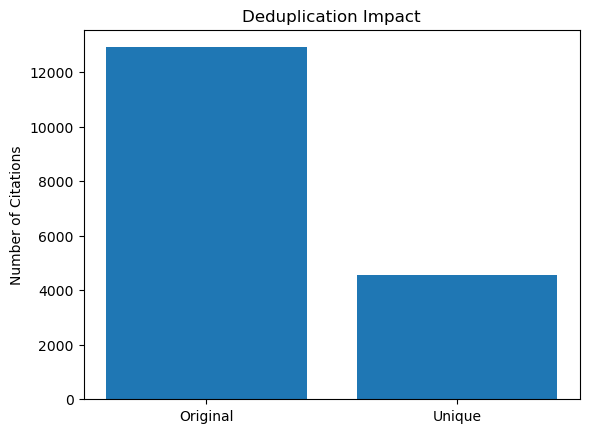

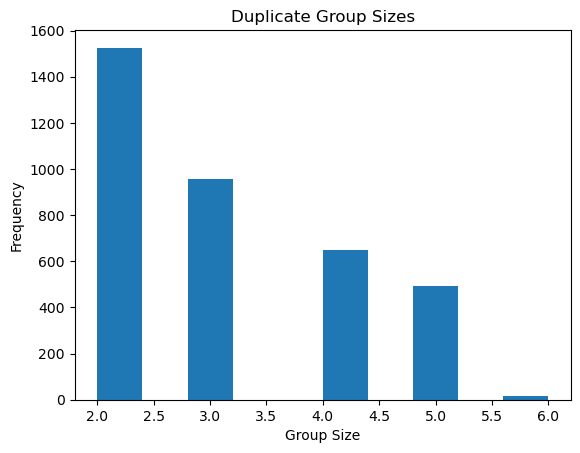




Most Reused Citations:

Wanless, S.B., Patton, C.S.*, Rimm-Kaufman, S.E., Deutsch, N.L. (2013). Setting-level influences on implementation of the Responsive Classroom approach. Prevention Science, 14, 40-51. doi: 10.1007/s11121-012-0294-1

Abenavoli,* R. M., Jennings, P. A., Harris*, A. R., Katz*, D. A., Gildea, S. M., & Greenberg, M. T. (2013). The protective effects of mindfulness against burnout among educators. Psychology of Education Review, 37(2), 57-69.

Investigator Initiated Industry Sponsored Study R Burket (PI) The Upjohn Company - Unrestricted Grant : "Anxiety Disorders in Psychiatrically Hospitalized Adolescents" Role: PI

Abenavoli, * R. M., Jennings, P. A., Harris*, A. R., Katz*, D. A., Gildea, S. M., & Greenberg, M. T. (2013). The protective effects of mindfulness against burnout among educators. Psychology of Education Review, 37(2), 57-69.

Wanless, S.B., Patton, C.S.*, Rimm-Kaufman, S.E., Deutsch, N.L. (2013). Setting-level influences on implementation of the Resp

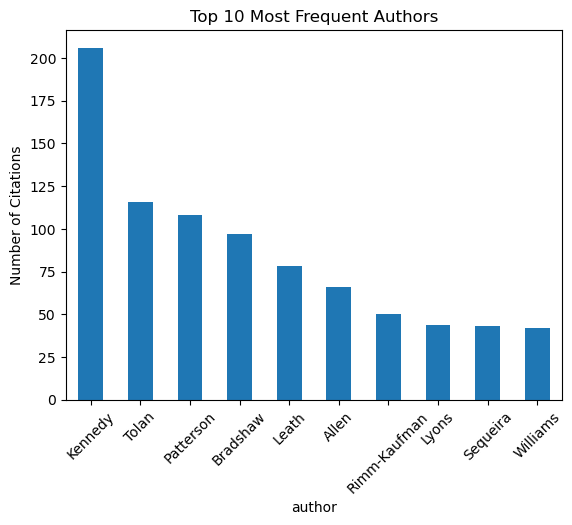



author
Kennedy         206
Tolan           116
Patterson       108
Bradshaw         97
Leath            78
Allen            66
Rimm-Kaufman     50
Lyons            44
Sequeira         43
Williams         42
Name: count, dtype: int64


Average reuse per duplicated citation: 3.042
Unique single-use citations: 931
Repeated citations: 3638
Potential low-quality citations: 0
Original vocab size: 23869
Unique vocab size: 23212


'dedup_citations.csv'

In [39]:
load_and_clean_citations('biblio_stabilized_candidate_citations_2026-04-22.csv', output_path='dedup_citations.csv', show_stats=True)